
# **Project Description**


# AG News Classification — TF-IDF + Classical NLP
  
**Goal:** Classify news headlines/articles into 4 categories (World, Sports, Business, Sci/Tech) using classical NLP techniques (no deep learning).  
**Objectives:**
- Explore the dataset and class distribution.
- Build a robust text-cleaning pipeline.
- Extract TF-IDF features with n-grams (uni/bi/tri).
- Train and compare Logistic Regression, MultinomialNB, and LinearSVC.
- Evaluate on validation and test sets; save best model + vectorizer.



# **Dataset description & files**

https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset/data
## Dataset description
The dataset contains two CSV files (train.csv and test.csv). Typical columns:
- `label` or `ClassIndex` (integers for the 4 classes)
- `title` (news headline)
- `description` (article short text / summary) — may be empty for some rows

**Plan:** Combine `title` + `description` into one `text` column and perform preprocessing. Use `train.csv` for training (split into train/validation) and `test.csv` for final evaluation.


# **Libraries**

In [ ]:

!pip install -q nltk scikit-learn pandas matplotlib seaborn joblib

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# **Load Dataset**

In [ ]:
from google.colab import files

print("Please upload 'train.csv':")
files.upload()

print("Please upload 'test.csv':")
files.upload()

print("Files uploaded successfully!")

Please upload 'train.csv':


Saving train.csv to train.csv
Please upload 'test.csv':


Saving test.csv to test.csv
Files uploaded successfully!


In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head(5)

Train shape: (120000, 3)
Test shape: (7600, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


# **Define categories**

In [ ]:
# Cell: Define mapping and descriptions
label_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
desc_map = {
    "World": "International news, politics, global events, diplomacy, conflicts.",
    "Sports": "Match results, tournaments, athlete news, transfers, game highlights.",
    "Business": "Market updates, company news, finance, economy, mergers/acquisitions.",
    "Sci/Tech": "Technology launches, scientific discoveries, research, gadgets, AI."
}
print("Label map:", label_map)
print("\nCategory descriptions:")
for k,v in desc_map.items():
    print(f"- {k}: {v}")


Label map: {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}

Category descriptions:
- World: International news, politics, global events, diplomacy, conflicts.
- Sports: Match results, tournaments, athlete news, transfers, game highlights.
- Business: Market updates, company news, finance, economy, mergers/acquisitions.
- Sci/Tech: Technology launches, scientific discoveries, research, gadgets, AI.


We map the categories in world, sports, Business and sci/tech to evaluate different aspects.

In [ ]:

print("Columns:", train.columns.tolist())
# show value counts for labels (if label column names are different, change to correct)
label_col = None
for c in train.columns:
    if 'label' in c.lower() or 'class' in c.lower():
        label_col = c
        break
if label_col is None:
    print("No obvious label column found. Columns:", train.columns)
else:
    print("Label column:", label_col)
    print(train[label_col].value_counts())

# show sample
train.sample(5)


Columns: ['Class Index', 'Title', 'Description']
Label column: Class Index
Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64


,Class Index,Title,Description
116307,2,Southern Miss. Beats N. Texas in New Orleans Bowl,NEW ORLEANS (Sports Network) - Dustin Almond ...
61479,3,Nokia: profits slump despite market share reco...,"October 15, 2004 4:59 PM GMT (Datamonitor) - N..."
70344,1,"Suicide blast toll rises, Afghan poll count ne...",An American woman and an Afghan girl died from...
46135,2,Yanks clinch East on Bernies blast,The Yankees had a chance to throw a party in t...
92270,3,Black day for Conrad,The hammer finally came down yesterday on Lord...


# **Create combined text column and cleaning function**

In [ ]:

# Identify columns automatically if columns have different names
cols = [c.lower() for c in train.columns]
title_col = None
desc_col = None
label_col = None
for c in train.columns:
    lc = c.lower()
    if 'title' in lc:
        title_col = c
    if 'desc' in lc or 'description' in lc:
        desc_col = c
    if 'label' in lc or 'class' in lc:
        label_col = c

print("Detected title_col:", title_col, "desc_col:", desc_col, "label_col:", label_col)

def combine_text(df):
    if title_col and desc_col:
        return (df[title_col].fillna('') + ' ' + df[desc_col].fillna('')).astype(str)
    elif title_col:
        return df[title_col].astype(str)
    else:
        # fallback to first non-label column
        cols = [c for c in df.columns if c != label_col]
        return df[cols[0]].astype(str)

train['text'] = combine_text(train)
test['text'] = combine_text(test)

# Show a few raw examples (first 3)
train[[label_col, 'text']].head(3)


Detected title_col: Title desc_col: Description label_col: Class Index


,Class Index,text
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters...


combine title and  description  to adjust names if different

# **Show raw examples per category**

In [ ]:
# Cell: show samples per category
for lbl, name in label_map.items():
    print("\n"+"="*40)
    print(f"Category: {name}  (label = {lbl})")
    print("="*40)
    sample_rows = train[train[label_col] == lbl]['text'].sample(3, random_state=42).tolist()
    for i, s in enumerate(sample_rows, 1):
        print(f"\nSample {i}:\n{s[:400]}")   # show first 400 chars to keep output small
    print("\n-------------------------")



Category: World  (label = 1)

Sample 1:
Explosion Rocks Baghdad Neighborhood BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.

Sample 2:
BBC reporters' log BBC correspondents record events in the Middle East and their thoughts as the funeral of the Palestinian leader Yasser Arafat takes place.

Sample 3:
Israel welcomes Rice nomination; Palestinians wary Israel on Tuesday warmly welcomed the naming of Condoleezza Rice as America #39;s top diplomat, but Palestinians were wary, saying the new Bush administration must put more energy into the quest for Middle East peace.

-------------------------

Category: Sports  (label = 2)

Sample 1:
Second Andre win in a row boosts US gold medal hopes Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wedn

Counts per category:
 Class Index
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


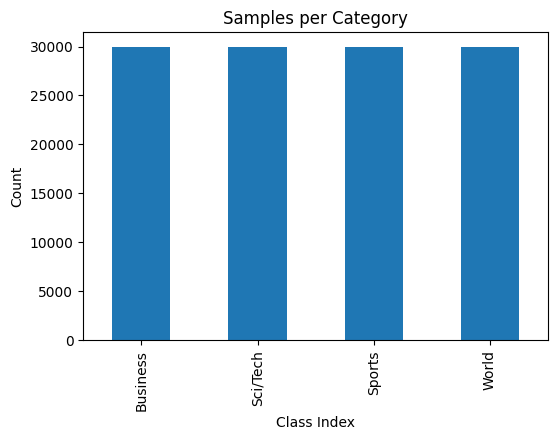

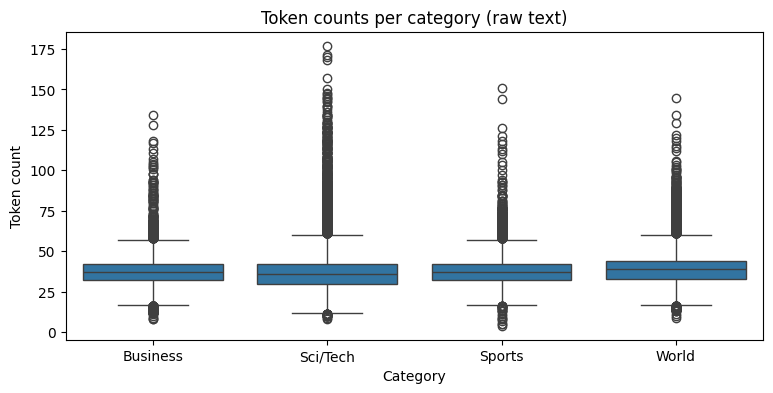

In [ ]:
# Cell: class counts and length stats
train['raw_len_chars'] = train['text'].astype(str).apply(len)
train['raw_len_tokens'] = train['text'].astype(str).apply(lambda x: len(str(x).split()))

# Class counts
counts = train[label_col].map(label_map).value_counts()
print("Counts per category:\n", counts)

# Plot counts
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
counts.plot(kind='bar')
plt.title("Samples per Category")
plt.ylabel("Count")
plt.show()

# Length distribution by category
import seaborn as sns
plt.figure(figsize=(9,4))
sns.boxplot(x=train[label_col].map(label_map), y=train['raw_len_tokens'])
plt.title("Token counts per category (raw text)")
plt.xlabel("Category")
plt.ylabel("Token count")
plt.show()


Show how many samples for each category and the token-length distribution use raw text lengths before cleaning the data.

In [ ]:
# Cell: top words per category (raw)
from sklearn.feature_extraction.text import CountVectorizer

def top_n_words(text_series, n=15, ngram_range=(1,1)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=10000)
    X = vec.fit_transform(text_series)
    sums = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top_idx = sums.argsort()[::-1][:n]
    return [(vocab[i], int(sums[i])) for i in top_idx]

for lbl, name in label_map.items():
    print("\n"+"="*30)
    print("Top words (raw) for", name)
    print("="*30)
    series = train[train[label_col] == lbl]['text']
    print(top_n_words(series, n=12))



Top words (raw) for World
[('39', 8923), ('said', 7745), ('iraq', 5837), ('ap', 5787), ('reuters', 5423), ('president', 4306), ('new', 3479), ('afp', 3388), ('minister', 3351), ('killed', 3179), ('people', 2873), ('government', 2670)]

Top words (raw) for Sports
[('39', 14826), ('ap', 6262), ('game', 4281), ('new', 4160), ('season', 3647), ('team', 3492), ('win', 3491), ('night', 3087), ('world', 3014), ('cup', 2762), ('league', 2761), ('year', 2677)]

Top words (raw) for Business
[('39', 11743), ('reuters', 8717), ('said', 7311), ('new', 6632), ('oil', 6386), ('gt', 5262), ('lt', 5234), ('stocks', 4518), ('company', 4320), ('prices', 4226), ('fullquote', 3626), ('percent', 3453)]

Top words (raw) for Sci/Tech
[('39', 9013), ('new', 7153), ('microsoft', 5145), ('gt', 4455), ('lt', 4441), ('ap', 3716), ('said', 3705), ('software', 3673), ('reuters', 3519), ('internet', 3387), ('company', 2924), ('space', 2646)]


This will help in  which words appear mostly  in each category before cleaning.

**Preprocessing**

In [ ]:
# Cell: Preprocessing function + apply
import re, string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

contractions = {"n't": " not", "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
                "'ve": " have", "'m": " am"}
stop_words = set(stopwords.words('english'))
# preserve negations
for neg in ['not', 'no', 'nor']:
    stop_words.discard(neg)

lemmatizer = WordNetLemmatizer()

def replace_contractions(text):
    for contr, rep in contractions.items():
        text = text.replace(contr, rep)
    return text

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = replace_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\d+(\.\d+)?', ' NUM ', text)            # numbers -> NUM
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    text = re.sub(r'[^a-z\sNUM]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = []
    for tok in text.split():
        if tok in stop_words:
            continue
        if len(tok) <= 1:
            continue
        tok = lemmatizer.lemmatize(tok)
        tokens.append(tok)
    return ' '.join(tokens)

# Apply cleaning
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

# Show before and after for a sample
train[['text','clean_text']].sample(3, random_state=42)


,text,clean_text
71787,"BBC set for major shake-up, claims newspaper L...",bbc set major shake claim newspaper london bri...
67218,Marsh averts cash crunch Embattled insurance b...,marsh averts cash crunch embattled insurance b...
54066,"Jeter, Yankees Look to Take Control (AP) AP - ...",jeter yankee look take control ap ap derek jet...


**EDA after cleaning**

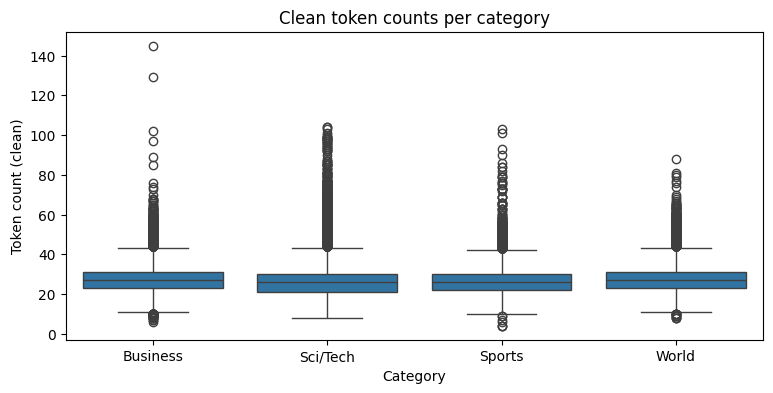


Top words (clean) for World
[('num', 27667), ('said', 7745), ('iraq', 5876), ('ap', 5787), ('reuters', 5423), ('president', 4349), ('minister', 3609), ('new', 3479), ('afp', 3388), ('killed', 3179), ('official', 3106), ('election', 3014)]

Top words (clean) for Sports
[('num', 58547), ('ap', 6262), ('game', 5938), ('win', 4380), ('team', 4163), ('new', 4160), ('season', 3855), ('year', 3853), ('night', 3135), ('world', 3038), ('league', 2797), ('victory', 2795)]

Top words (clean) for Business
[('num', 42060), ('said', 7311), ('reuters', 6903), ('new', 6632), ('oil', 6390), ('stock', 6157), ('company', 5481), ('price', 5365), ('gt', 5255), ('lt', 5234), ('year', 4500), ('profit', 3730)]

Top words (clean) for Sci/Tech
[('num', 33985), ('new', 7154), ('microsoft', 5143), ('lt', 4441), ('gt', 4413), ('company', 4151), ('ap', 3717), ('said', 3705), ('software', 3677), ('service', 3490), ('internet', 3398), ('year', 3373)]


In [ ]:
# Cell: EDA post-clean
train['clean_len_tokens'] = train['clean_text'].apply(lambda x: len(x.split()))

# Boxplot of cleaned token lengths by category
plt.figure(figsize=(9,4))
sns.boxplot(x=train[label_col].map(label_map), y=train['clean_len_tokens'])
plt.title("Clean token counts per category")
plt.xlabel("Category")
plt.ylabel("Token count (clean)")
plt.show()

# Top words per category (clean)
for lbl, name in label_map.items():
    print("\n"+"="*30)
    print("Top words (clean) for", name)
    print("="*30)
    series = train[train[label_col] == lbl]['clean_text']
    print(top_n_words(series, n=12))


This shows how cleaning changed the frequent tokens and how categories now  clearly distinguishing words.

**Feature & Target declaration**

In [ ]:
# Cell: Define X and y and split
X = train['clean_text']
y = train[label_col]     # integer labels

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("Feature (X_train) sample:", X_train.iloc[0])
print("Target (y_train) sample:", y_train.iloc[0], "->", label_map[y_train.iloc[0]])


X_train shape: (96000,)
X_val shape: (24000,)
Example feature (X_train) sample: clijsters unsure latest injury say hewitt tokyo reuters belgian kim clijsters unsure exact nature injury prematurely ended season fiance lleyton hewitt said wednesday
Example target (y_train) sample: 2 -> Sports


# **TF-IDF Vectorization (uni/bi/tri experiments)**

## TF-IDF setup and n-gram experiments
We will try TF-IDF with:
- unigrams (1,1)
- unigrams + bigrams (1,2)
- unigrams + bigrams + trigrams (1,3)

Parameters to consider:
- `max_features` (e.g., 20000–50000)
- `min_df` (e.g., 3 or 5) to ignore very rare terms
- `max_df` (e.g., 0.8) to ignore extremely common terms


In [ ]:
# Cell: TF-IDF helper function
from sklearn.feature_extraction.text import TfidfVectorizer

def prepare_tfidf(ngram_range=(1,2), max_features=20000, min_df=3, max_df=0.8):
    tfidf = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=min_df, max_df=max_df)
    X_tr = tfidf.fit_transform(X_train)
    X_vl = tfidf.transform(X_val)
    X_te = tfidf.transform(test['clean_text'])
    print("TF-IDF fitted with ngram_range=", ngram_range, "-> shape:", X_tr.shape)
    return tfidf, X_tr, X_vl, X_te

# Example: uni+bi
tfidf, X_train_tfidf, X_val_tfidf, X_test_tfidf = prepare_tfidf(ngram_range=(1,2), max_features=30000)


TF-IDF fitted with ngram_range= (1, 2) -> shape: (96000, 30000)


 We convert cleaned text into numeric features using TF-IDF.
 We  tried ngram_range=(1,1), (1,2) and (1,3) to compare.
 max_features  (e.g., 20000–30000)

# **Train 3 models and evaluate**

## Train three classical models
We will fit:
- Logistic Regression
- Multinomial Naive Bayes
- LinearSVC (SVM)

We will compare validation accuracy and classification reports.


In [ ]:
# Cell: Train & evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    'MultinomialNB': MultinomialNB(),
    'LinearSVC': LinearSVC(max_iter=10000, random_state=42)
}

results = {}
for name, model in models.items():
    print("\n--- Training", name)
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, preds)
    print(name, "Validation Accuracy:", round(acc,4))
    print(classification_report(y_val, preds, zero_division=0))
    results[name] = {'model': model, 'val_acc': acc, 'val_preds': preds}



--- Training LogisticRegression
LogisticRegression Validation Accuracy: 0.9231
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      6000
           2       0.96      0.98      0.97      6000
           3       0.90      0.90      0.90      6000
           4       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000


--- Training MultinomialNB
MultinomialNB Validation Accuracy: 0.9112
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      6000
           2       0.95      0.98      0.96      6000
           3       0.89      0.87      0.88      6000
           4       0.88      0.90      0.89      6000

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91  

# **Confusion matrix and results table**

## Results and confusion matrix
Pick the best model by validation accuracy. Show confusion matrix for analysis.


Best on val: LogisticRegression with acc 0.9230833333333334


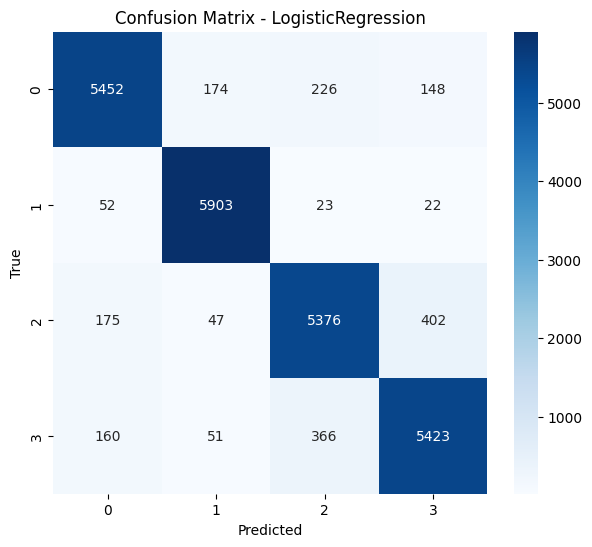

,Model,Val Accuracy
0,LogisticRegression,0.923083
2,LinearSVC,0.921792
1,MultinomialNB,0.911167


In [ ]:
# Confusion Matrix for best model (pick best by val_acc)
best_name = max(results, key=lambda k: results[k]['val_acc'])
best_model = results[best_name]['model']
print("Best on val:", best_name, "with acc", results[best_name]['val_acc'])

# Confusion matrix
cm = confusion_matrix(y_val, results[best_name]['val_preds'])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Results table
res_table = pd.DataFrame([
    {'Model': k, 'Val Accuracy': v['val_acc']} for k,v in results.items()
]).sort_values('Val Accuracy', ascending=False)
res_table


# **Evaluate on test.csv and save predictions**

In [ ]:
# Cell: evaluate or save predictions
test_preds = best_model.predict(X_test_tfidf)

if label_col in test.columns:
    print("Test accuracy:", accuracy_score(test[label_col], test_preds))
    print(classification_report(test[label_col], test_preds, zero_division=0))
else:
    out = test.copy()
    out['predicted_label'] = test_preds
    out['predicted_label_text'] = out['predicted_label'].map(label_map)
    out[['text','predicted_label','predicted_label_text']].to_csv('agnews_test_predictions.csv', index=False)
    print("Saved agnews_test_predictions.csv")

# Save TF-IDF and best model
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(best_model, f'{best_name}_model.joblib')
print("Saved tfidf_vectorizer.joblib and", f'{best_name}_model.joblib')


Test accuracy: 0.9186842105263158
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      1900
           2       0.95      0.98      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600

Saved tfidf_vectorizer.joblib and LogisticRegression_model.joblib
